<a href="https://colab.research.google.com/github/Amitabh-Phule/Deep-Learning/blob/main/DL_Exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving imdb_movies.csv.zip to imdb_movies.csv (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile('imdb_movies.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
import pandas as pd

df = pd.read_csv('imdb_movies.csv')

df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [ ]:
print(df.columns)

Index(['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title',
       'status', 'orig_lang', 'budget_x', 'revenue', 'country'],
      dtype='object')


In [ ]:
# Keep required columns
df = df[['overview', 'score']].copy()

# Remove null values
df = df.dropna()

# Create sentiment
df['sentiment'] = df['score'].apply(lambda x: 1 if x >= 7 else 0)

# Split classes
df_pos = df[df['sentiment'] == 1]
df_neg = df[df['sentiment'] == 0]

print("Before balancing:")
print(df['sentiment'].value_counts())

# 🔥 BALANCE DATASET (CRITICAL)
df_pos = df_pos.sample(n=len(df_neg), random_state=42)

# Combine
df = pd.concat([df_pos, df_neg])

# Shuffle dataset
df = df.sample(frac=1, random_state=42)

print("After balancing:")
print(df['sentiment'].value_counts())

Before balancing:
sentiment
1    9967
0     211
Name: count, dtype: int64
After balancing:
sentiment
1    211
0    211
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 5000
max_len = 200

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df['overview'])

sequences = tokenizer.texts_to_sequences(df['overview'])

X = pad_sequences(sequences, maxlen=max_len)
y = df['sentiment'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

def build_rnn():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=max_len),
        SimpleRNN(32),
        Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

rnn_model = build_rnn()
rnn_history = rnn_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5134 - loss: 0.6744 - val_accuracy: 0.5412 - val_loss: 0.6408
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9555 - loss: 0.4654 - val_accuracy: 0.5412 - val_loss: 0.6233
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 0.2659 - val_accuracy: 0.6000 - val_loss: 0.6240
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.1237 - val_accuracy: 0.6235 - val_loss: 0.6116
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.0635 - val_accuracy: 0.6353 - val_loss: 0.6083
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0366 - val_accuracy: 0.6471 - val_loss: 0.6058
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.0242 - val_accuracy: 0.6353 - val_loss: 0.6129
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0181 - val_accuracy: 0.6588 - val_loss: 0.

In [ ]:
from tensorflow.keras.layers import LSTM

def build_lstm():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=max_len),
        LSTM(32),
        Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

lstm_model = build_lstm()
lstm_history = lstm_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5786 - loss: 0.6863 - val_accuracy: 0.5882 - val_loss: 0.6743
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6855 - loss: 0.6295 - val_accuracy: 0.5765 - val_loss: 0.6317
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6914 - loss: 0.5642 - val_accuracy: 0.5294 - val_loss: 0.6276
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7982 - loss: 0.4611 - val_accuracy: 0.6118 - val_loss: 0.6251
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9407 - loss: 0.2646 - val_accuracy: 0.6588 - val_loss: 0.6852
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9881 - loss: 0.1103 - val_accuracy: 0.6235 - val_loss: 0.8039
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 1.0000 - loss: 0.0485 - val_accuracy: 0.5765 - val_loss: 0.9210
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 1.0000 - loss: 0.0390 - val_accuracy: 0.6471 - v

In [ ]:
from tensorflow.keras.layers import GRU

def build_gru():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=max_len),
        GRU(32),
        Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

gru_model = build_gru()
gru_history = gru_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.4866 - loss: 0.6899 - val_accuracy: 0.5882 - val_loss: 0.6806
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8368 - loss: 0.6606 - val_accuracy: 0.5647 - val_loss: 0.6673
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.8398 - loss: 0.6098 - val_accuracy: 0.6118 - val_loss: 0.6434
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.9021 - loss: 0.5061 - val_accuracy: 0.6353 - val_loss: 0.6104
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.9347 - loss: 0.3575 - val_accuracy: 0.6706 - val_loss: 0.6516
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9733 - loss: 0.1784 - val_accuracy: 0.6706 - val_loss: 0.7128
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9941 - loss: 0.0533 - val_accuracy: 0.6588 - val_loss: 0.8845
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 1.0000 - loss: 0.0137 - val_accuracy: 0.6824 -

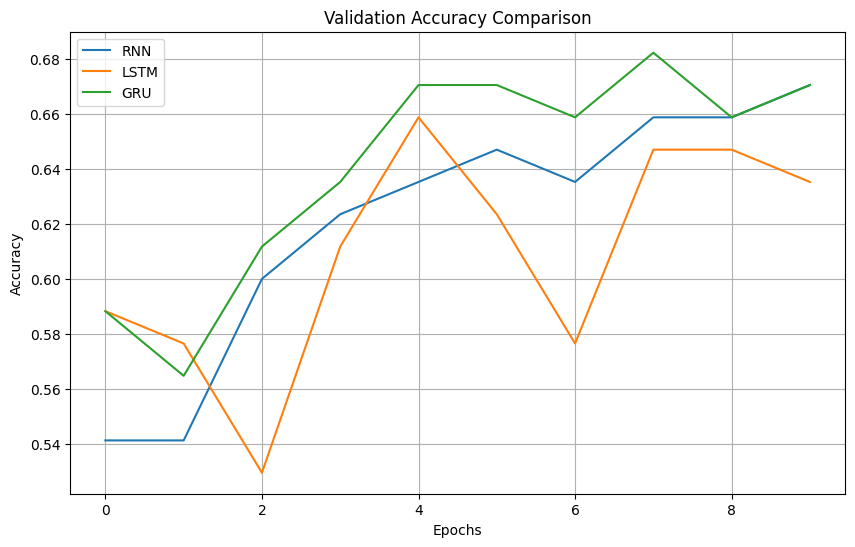

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(gru_history.history['val_accuracy'], label='GRU')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

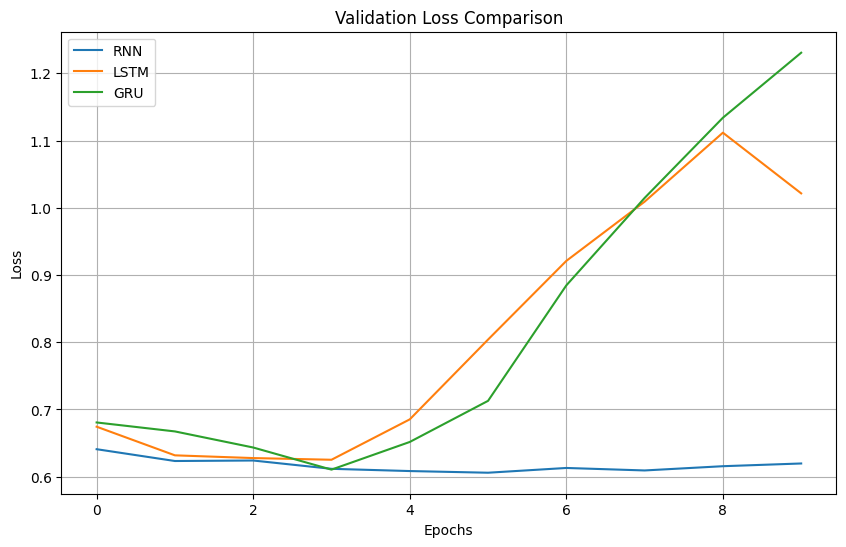

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(rnn_history.history['val_loss'], label='RNN')
plt.plot(lstm_history.history['val_loss'], label='LSTM')
plt.plot(gru_history.history['val_loss'], label='GRU')

plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [ ]:
print("Final Accuracy:")
print("RNN:", rnn_history.history['val_accuracy'][-1])
print("LSTM:", lstm_history.history['val_accuracy'][-1])
print("GRU:", gru_history.history['val_accuracy'][-1])

Final Accuracy:
RNN: 0.6705882549285889
LSTM: 0.6352941393852234
GRU: 0.6705882549285889
